In [1]:
!nvidia-smi
!lscpu
!free -h
!cat /etc/os-release
!df -h

Fri Aug  7 00:22:32 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   45C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
SEED = 42
BATCH_SIZE = 256
LR = 1e-3
WEIGHT_DECAY = 0.05
FL_GAMMA = 2.0
NUM_WORKERS = 3
PATIENCE = 15
N_EPOCHS = 100

INPUT_DATASETS_ROOT = "/kaggle/input/datasets/labsys443/tilda-hku-patched"

In [3]:
import os
import gc
import sys
import json
import time
import copy
import h5py
import random
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from datetime import datetime
from typing import Dict, Any
import urllib.request

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
torch.set_float32_matmul_precision('medium')

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pytorch_lightning.loggers import CSVLogger

import torchmetrics
from torchmetrics.classification import (
    MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    BinaryF1Score, BinaryAccuracy, BinaryPrecision, BinaryRecall
)
from sklearn.metrics import ( 
    f1_score, accuracy_score, precision_score, 
    recall_score, classification_report, confusion_matrix, 
    ConfusionMatrixDisplay
)

import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

from kaggle_secrets import UserSecretsClient
webhook_url = UserSecretsClient().get_secret("DISCORD_WEBHOOK")

!pip freeze > requirements.txt

def setup_logger(output_dir: str = None) -> logging.Logger:
    """
    Configures and returns a structured logger for experiment tracking.
    Outputs to stdout and optionally logs to a text file in output_dir.
    """
    logger = logging.getLogger("experiment")
    logger.setLevel(logging.INFO)
    
    # Prevent duplicate logs if handler is already attached
    if logger.hasHandlers():
        logger.handlers.clear()

    # Define standard log format
    formatter = logging.Formatter(
        fmt="[%(asctime)s] [%(levelname)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    )

    # Console Handler (stdout)
    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    # File Handler (optional: saves log output directly to experiment directory)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        file_handler = logging.FileHandler(f"{output_dir}/experiment.log")
        file_handler.setFormatter(formatter)
        logger.addHandler(file_handler)

    return logger

def dispatch_discord_notification(
    summary: Dict[str, Any]
) -> None:
    """
    Accepts experiment output dictionary, formats message payload, and posts to Discord via Kaggle Secrets.
    """
    logger = logging.getLogger("experiment")
    

    # Build metric summary lines
    metric_lines = [
        f"• **{metric}**: `{data['mean']:.4f} ± {data['std']:.4f}`"
        for metric, data in summary["cv_summary"].items()
    ]
    metrics_block = "\n".join(metric_lines)
    
    ratio_str = f"`{summary['undersample_ratio']}`" if summary['undersample_ratio'] is not None else "`N/A`"

    message = (
        f"**Training Pipeline Execution Complete**\n\n"
        f"**Experiment Configuration:**\n"
        f"• **Dataset:** `{summary['dataset_name']}`\n"
        f"• **Patch Size:** `{summary['resolution']}x{summary['resolution']} px`\n"
        f"• **Model:** `{summary['model_name']}`\n"
        f"• **Experiment Type:** `{summary['experiment_type'].upper()}`\n"
        f"• **Undersample Ratio:** {ratio_str}\n"
        f"• **Total Execution Time:** `{summary['execution_time']}`\n\n"
        f"**Cross-Validation Summary Report (5-Fold):**\n"
        f"{metrics_block}"
    )

    payload = json.dumps({"content": message}).encode("utf-8")
    headers = {
        "Content-Type": "application/json",
        "User-Agent": "PyTorch-Lightning-Pipeline"
    }

    try:
        req = urllib.request.Request(webhook_url, data=payload, headers=headers)
        with urllib.request.urlopen(req) as response:
            if response.status in (200, 204):
                logger.info("Discord notification sent successfully.")
            else:
                logger.warning(f"Discord API HTTP status: {response.status}")
    except Exception as e:
        logger.warning(f"Failed to deliver Discord webhook: {e}")

def set_seed(seed=42):
    pl.seed_everything(seed, workers=True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

Seed set to 42


In [4]:
class MulticlassFocalLoss(nn.Module):
    def __init__(
        self,
        alpha=None,
        gamma=FL_GAMMA,
        reduction="mean",
        ignore_index=-100,
    ):
        super().__init__()

        if reduction not in {"mean", "sum", "none"}:
            raise ValueError("reduction must be 'mean', 'sum', or 'none'")

        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index

        if alpha is not None:
            alpha = torch.as_tensor(alpha, dtype=torch.float32)
            if alpha.ndim != 1:
                raise ValueError("alpha must be a 1D tensor or sequence")
            self.register_buffer("alpha", alpha)
        else:
            self.alpha = None

    def forward(self, inputs, targets):
        valid_mask = targets != self.ignore_index

        targets_clean = targets.masked_fill(~valid_mask, 0)

        log_probs = F.log_softmax(inputs, dim=1)
        log_pt = log_probs.gather(1, targets_clean.unsqueeze(1)).squeeze(1)
        pt = log_pt.exp()

        loss = -((1.0 - pt) ** self.gamma) * log_pt

        if self.alpha is not None:
            if self.alpha.numel() != inputs.size(1):
                raise ValueError(
                    f"alpha has {self.alpha.numel()} elements, "
                    f"but expected {inputs.size(1)}"
                )
            loss = self.alpha[targets_clean] * loss

        loss = loss[valid_mask]

        if loss.numel() == 0:
            return inputs.new_tensor(0.0)

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        else:  # "none"
            return loss

def get_transforms(model_name: str, is_training: bool = True, target_size: int = None):
    """
    Constructs an Albumentations pipeline that ingests raw uint8 NumPy images [0, 255],
    applies spatial data augmentations, normalizes using timm model statistics, 
    and outputs a C x H x W PyTorch Tensor.
    """
    data_config = timm.data.resolve_model_data_config(model=model_name)
    
    mean = data_config['mean']
    std = data_config['std']
    input_size = target_size if target_size is not None else data_config['input_size'][-1]
    
    transform_list = [
        A.Resize(height=input_size, width=input_size)
    ]
    
    if is_training:
        transform_list.extend([
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.5),
            A.RandomRotate90(p=0.5)
        ])
    
    # A.Normalize scales uint8 [0, 255] to [0.0, 1.0] internally via max_pixel_value,
    # then computes: (x - mean) / std
    transform_list.extend([
        A.Normalize(mean=mean, std=std, max_pixel_value=255.0),
        ToTensorV2()
    ])
    
    return A.Compose(transform_list), input_size

class TextileDataset(Dataset):
    """
    PyTorch Dataset for HDF5 textile patch containers.
    Delivers raw uint8 patches [0, 255] to downstream transformations without 
    applying domain-specific scaling or normalization.
    """
    def __init__(
        self,
        h5_path: str,
        indices: np.ndarray = None,
        target_key: str = 'y_multi',
        transform = None,
        in_memory: bool = False
    ):
        self.h5_path = h5_path
        self.target_key = target_key
        self.transform = transform
        self.in_memory = in_memory
        self.hf = None  # Lazy handle for worker-safe multiprocessing

        with h5py.File(self.h5_path, 'r') as hf:
            total_samples = hf['X'].shape[0]
            if indices is None:
                self.indices = np.arange(total_samples)
            else:
                self.indices = np.array(indices, dtype=np.int64)

        if self.in_memory:
            with h5py.File(self.h5_path, 'r') as hf:
                self.X = hf['X'][self.indices]
                self.y = hf[self.target_key][self.indices]
        else:
            self.X = None
            self.y = None

    def __len__(self) -> int:
        return len(self.indices)

    def _init_handle(self):
        if self.hf is None:
            self.hf = h5py.File(self.h5_path, 'r')

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        if self.in_memory:
            image = self.X[idx]
            label_val = self.y[idx]
        else:
            self._init_handle()
            real_idx = self.indices[idx]
            image = self.hf['X'][real_idx]
            label_val = self.hf[self.target_key][real_idx]

        # Standardize 2D grayscale or single-channel inputs to 3-channel (H, W, 3) uint8
        if image.ndim == 2:
            image = np.stack([image] * 3, axis=-1)
        elif image.ndim == 3 and image.shape[-1] == 1:
            image = np.repeat(image, 3, axis=-1)

        # Apply spatial transforms and normalization (Albumentations pipeline)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        else:
            # Fallback for raw dataset inspection without transforms: convert (H, W, C) -> (C, H, W) Tensor
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0

        label = torch.tensor(label_val, dtype=torch.long)
        return image, label

    def __del__(self):
        if self.hf is not None:
            self.hf.close()

class LightningModel(pl.LightningModule):
    """
    PyTorch Lightning Module for Textile Defect Classification.
    Supports weighted cross-entropy, focal loss, dual-granularity metrics 
    (multiclass defect taxonomy vs. binary good/defective detection), 
    and robust GPU buffer migration.
    """
    def __init__(
        self,
        model_name: str,
        num_classes: int,
        experiment_type: str = "standard",
        class_weights: list[float] = None,
        lr: float = 1e-3,
        weight_decay: float = 1e-4,
        fl_gamma: float = 2.0
    ):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        self.weight_decay = weight_decay
        self.num_classes = num_classes

        # Instantiate backbone architecture via TIMM
        self.model = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=num_classes,
            in_chans=3
        )

        # Register loss weights as module buffer for automatic GPU device placement
        if class_weights is not None:
            self.register_buffer('class_weights_tensor', torch.tensor(class_weights, dtype=torch.float32))
        else:
            self.class_weights_tensor = None

        # Loss Function Factory
        if experiment_type == "wce" and self.class_weights_tensor is not None:
            self.criterion = nn.CrossEntropyLoss(weight=self.class_weights_tensor)
        elif experiment_type == "focal_loss" and self.class_weights_tensor is not None:
            # Assumes custom or torchmetrics MulticlassFocalLoss
            self.criterion = MulticlassFocalLoss(alpha=self.class_weights_tensor, gamma=fl_gamma)
        else:
            self.criterion = nn.CrossEntropyLoss()

        # Split-Isolated Multiclass Metrics (Macro Averaged)
        self.train_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.val_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.test_multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')

        # Split-Isolated Binary Metrics (Defective vs. Good; Index 0 assumed Good)
        self.val_bin_f1 = BinaryF1Score()
        self.test_bin_f1 = BinaryF1Score()
        self.val_bin_acc = BinaryAccuracy()
        self.test_bin_acc = BinaryAccuracy()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

    def training_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int) -> torch.Tensor:
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)

        preds = torch.argmax(logits, dim=1)
        self.train_multi_f1.update(preds, labels)

        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('train_f1_macro', self.train_multi_f1, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def _shared_eval_step(self, batch: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Derive binary labels (0 = Good, >0 = Defective)
        bin_labels = (labels > 0).long()
        bin_probs = probs[:, 1:].sum(dim=1)  # Aggregate probability across all defect classes

        return loss, preds, labels, bin_probs, bin_labels

    def validation_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int):
        loss, preds, labels, bin_probs, bin_labels = self._shared_eval_step(batch)

        self.val_multi_f1.update(preds, labels)
        self.val_bin_f1.update(bin_probs, bin_labels)
        self.val_bin_acc.update(bin_probs, bin_labels)

        self.log('val_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1_macro', self.val_multi_f1, on_step=False, on_epoch=True, prog_bar=True)
        self.log('val_f1_bin', self.val_bin_f1, on_step=False, on_epoch=True)
        self.log('val_acc_bin', self.val_bin_acc, on_step=False, on_epoch=True)

    def test_step(self, batch: tuple[torch.Tensor, torch.Tensor], batch_idx: int):
        loss, preds, labels, bin_probs, bin_labels = self._shared_eval_step(batch)

        self.test_multi_f1.update(preds, labels)
        self.test_bin_f1.update(bin_probs, bin_labels)
        self.test_bin_acc.update(bin_probs, bin_labels)

        self.log('test_loss', loss, on_step=False, on_epoch=True)
        self.log('test_f1_macro', self.test_multi_f1, on_step=False, on_epoch=True)
        self.log('test_f1_bin', self.test_bin_f1, on_step=False, on_epoch=True)
        self.log('test_acc_bin', self.test_bin_acc, on_step=False, on_epoch=True)

    def configure_optimizers(self):
        optimizer = optim.AdamW(
            self.parameters(),
            lr=self.lr,
            weight_decay=self.weight_decay
        )
        
        # Safeguard learning rate scheduler if max_epochs is undefined
        max_epochs = self.trainer.max_epochs if self.trainer and self.trainer.max_epochs else 30
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)
        
        return [optimizer], [scheduler]

In [5]:
def get_balanced_indices(
    h5_path: str, 
    target_key: str = 'y_multi', 
    undersample_ratio: float = 1.0, 
    subset_indices: np.ndarray = None, 
    seed: int = SEED
) -> np.ndarray:
    """
    Subsamples majority instances within a specific index subset while preserving
    all minority instances based on the provided undersample ratio.
    """

    set_seed(SEED)
    
    with h5py.File(h5_path, 'r') as hf:
        labels = hf[target_key][:]

    if subset_indices is not None:
        labels = labels[subset_indices]
        base_indices = subset_indices
    else:
        base_indices = np.arange(len(labels))

    rng = np.random.default_rng(seed)
    
    # Defective vs Good instance identification
    defect_mask = labels > 0
    good_mask = labels == 0

    defect_indices = base_indices[defect_mask]
    good_indices = base_indices[good_mask]

    num_defects = len(defect_indices)
    target_good_count = int(num_defects * undersample_ratio)

    if target_good_count < len(good_indices):
        sampled_good_indices = rng.choice(good_indices, size=target_good_count, replace=False)
    else:
        sampled_good_indices = good_indices

    final_indices = np.concatenate([defect_indices, sampled_good_indices])
    rng.shuffle(final_indices)
    
    return final_indices

def get_predictions_and_metrics(model, loader, device=None):
    """
    Evaluates model performance across multiclass taxonomy and aggregated binary metrics.
    Aggregates total defect probability via softmax summation for robust binary evaluation.
    """
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    
    all_logits = []
    all_targets = []
    
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            logits = model(x)
            all_logits.append(logits.cpu())
            all_targets.append(y.cpu())
            
    # Concatenate CPU tensors efficiently
    all_logits = torch.cat(all_logits, dim=0)
    y_true = torch.cat(all_targets, dim=0).numpy()
    
    # Multiclass Probabilities & Predictions
    probs = torch.softmax(all_logits, dim=1).numpy()
    y_pred = np.argmax(probs, axis=1)
    
    # Aggregate Binary Probabilities (Class 0 = Good, Classes > 0 = Defect)
    if probs.shape[1] > 1:
        bin_probs = probs[:, 1:].sum(axis=1)
    else:
        bin_probs = probs[:, 0]
        
    y_true_bin = (y_true > 0).astype(int)
    y_pred_bin = (bin_probs >= 0.5).astype(int)
    
    metrics = {
        'F1 Macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision Macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall Macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'Binary Accuracy': accuracy_score(y_true_bin, y_pred_bin),
        'Binary F1': f1_score(y_true_bin, y_pred_bin, zero_division=0),
        'Binary Precision': precision_score(y_true_bin, y_pred_bin, zero_division=0),
        'Binary Recall': recall_score(y_true_bin, y_pred_bin, zero_division=0)
    }
    
    return metrics, y_true, y_pred, y_true_bin, y_pred_bin

def plot_fold_metrics(csv_path: str, fold_num: int) -> None:
    """
    Plots training and validation losses alongside classification metrics 
    for a specific cross-validation fold using PyTorch Lightning CSVLogger outputs.
    """
    if not os.path.exists(csv_path):
        logger.warning(f"CSV log file not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    if df.empty or 'epoch' not in df.columns:
        logger.warning(f"CSV log file is empty or missing 'epoch' column: {csv_path}")
        return

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # 1. Loss Curves Plotting
    if 'train_loss' in df.columns:
        train_loss = df.dropna(subset=['train_loss']).groupby('epoch')['train_loss'].mean()
        axes[0].plot(train_loss.index, train_loss.values, label='Train Loss', color='#2b5c8f', alpha=0.8, linewidth=2)

    if 'val_loss' in df.columns:
        val_loss = df.dropna(subset=['val_loss']).groupby('epoch')['val_loss'].mean()
        axes[0].plot(val_loss.index, val_loss.values, label='Val Loss', color='#d95f02', marker='o', linewidth=2)

    axes[0].set_title(f"Fold {fold_num} - Loss Curves", fontsize=12)
    axes[0].set_xlabel("Epoch", fontsize=10)
    axes[0].set_ylabel("Loss", fontsize=10)
    axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
    axes[0].legend(loc='upper right')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Performance Metrics Plotting (Aligned with LightningModel)
    target_metrics = ['val_acc_bin', 'val_f1_bin', 'val_f1_macro']
    metric_colors = {
        'val_acc_bin': '#7570b3',
        'val_f1_bin': '#1b9e77',
        'val_f1_macro': '#e7298a'
    }

    available_metrics = [m for m in target_metrics if m in df.columns]

    if available_metrics:
        for metric in available_metrics:
            # Independent filtering per metric to prevent multi-row step dropping
            metric_series = df.dropna(subset=[metric]).groupby('epoch')[metric].mean()
            axes[1].plot(
                metric_series.index, 
                metric_series.values, 
                label=metric, 
                color=metric_colors.get(metric, '#333333'), 
                linewidth=2,
                marker='s',
                markersize=4
            )
        axes[1].set_title(f"Fold {fold_num} - Validation Metrics", fontsize=12)
        axes[1].set_xlabel("Epoch", fontsize=10)
        axes[1].set_ylabel("Score", fontsize=10)
        axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
        axes[1].legend(loc='lower right')
        axes[1].grid(True, linestyle='--', alpha=0.5)
    else:
        axes[1].text(0.5, 0.5, "No target validation metrics found", ha='center', va='center', transform=axes[1].transAxes)
        axes[1].set_title(f"Fold {fold_num} - Validation Metrics (Missing)")

    plt.tight_layout()
    plt.show()


def plot_final_model_metrics(csv_path: str, model_title: str = "Final Model") -> None:
    """
    Plots training loss and macro F1 score trajectories for final model retraining 
    on the full development dataset.
    """

    logger = logging.getLogger("experiment")
    
    if not os.path.exists(csv_path):
        logger.warning(f"CSV log file not found: {csv_path}")
        return

    df = pd.read_csv(csv_path)
    if df.empty or 'epoch' not in df.columns:
        logger.warning(f"CSV log file is empty or missing 'epoch' column: {csv_path}")
        return

    # Extract training loss and training macro F1 score
    train_loss = (
        df.dropna(subset=['train_loss'])
        .groupby('epoch')['train_loss']
        .mean() if 'train_loss' in df.columns else pd.Series(dtype=float)
    )
    train_f1 = (
        df.dropna(subset=['train_f1_macro'])
        .groupby('epoch')['train_f1_macro']
        .mean() if 'train_f1_macro' in df.columns else pd.Series(dtype=float)
    )

    if train_loss.empty:
        logger.warning(f"No 'train_loss' data found to plot in file: {csv_path}")
        return

    fig, ax1 = plt.subplots(figsize=(9, 5))

    # Primary Axis: Training Loss
    color_loss = '#1f77b4'
    ax1.set_xlabel('Epoch', fontsize=10)
    ax1.set_ylabel('Train Loss', color=color_loss, fontsize=10)
    line1 = ax1.plot(
        train_loss.index, 
        train_loss.values, 
        color=color_loss, 
        linewidth=2, 
        marker='o', 
        label='Train Loss'
    )
    ax1.tick_params(axis='y', labelcolor=color_loss)
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.grid(True, linestyle='--', alpha=0.5)

    lines = line1
    labels = [l.get_label() for l in lines]

    # Secondary Axis: Training Macro F1 (Dual-Axis Trajectory)
    if not train_f1.empty:
        ax2 = ax1.twinx()
        color_f1 = '#2ca02c'
        ax2.set_ylabel('Train F1 (Macro)', color=color_f1, fontsize=10)
        line2 = ax2.plot(
            train_f1.index, 
            train_f1.values, 
            color=color_f1, 
            linewidth=2, 
            marker='s', 
            label='Train F1 Macro'
        )
        ax2.tick_params(axis='y', labelcolor=color_f1)
        ax2.set_ylim(0.0, 1.05)
        lines += line2
        labels += [l.get_label() for l in line2]

    plt.title(f"{model_title} - Full Retraining Trajectory", fontsize=12)
    ax1.legend(lines, labels, loc='center right')
    plt.tight_layout()
    plt.show()

def run_experiment(
    dataset_name: str = "HKU", 
    resolution: int = 64,
    model_name: str = 'fastvit_t8.apple_in1k', 
    experiment_type: str = "wce", 
    undersample_ratio: float = None, 
    num_epochs: int = 50, 
    batch_size: int = 64,
    input_datasets_root: str = "/kaggle/input/datasets/angelogoes/tilda-hku-patched",
    experiments_root: str = "/kaggle/working/experiments",
    seed: int = SEED
) -> None:
    """
    Executes 5-fold cross-validation mapped via JSON split manifests, followed 
    by full development set retraining up to the median optimal epoch.
    """

    start_time = time.time()
    
    # 1. Resolve Paths
    dataset_dir = os.path.join(input_datasets_root, f"{dataset_name.lower()}_{resolution}")
    dev_set_path = os.path.join(dataset_dir, f"dev_set_{resolution}.h5")
    json_split_path = os.path.join(input_datasets_root, "metadata", f"{dataset_name.lower()}_splits_seed{seed}.json")
    
    ratio_str = f"_ratio{undersample_ratio}" if undersample_ratio is not None else ""
    output_dir = os.path.join(experiments_root, f"{dataset_name}_{resolution}_{experiment_type}{ratio_str}_{model_name}")
    os.makedirs(output_dir, exist_ok=True)
    
    sys_logger = setup_logger(output_dir=output_dir)
    sys_logger.info(f"Running Experiment: {dataset_name} | {resolution}px | {model_name} | {experiment_type.upper()}")
    
    if not os.path.exists(dev_set_path):
        raise FileNotFoundError(f"Development HDF5 dataset not found at: {dev_set_path}")
    if not os.path.exists(json_split_path):
        raise FileNotFoundError(f"JSON split manifest not found at: {json_split_path}")

    # 2. Load JSON Manifest & HDF5 Metadata
    with open(json_split_path, 'r', encoding='utf-8') as f:
        split_manifest = json.load(f)
        
    with h5py.File(dev_set_path, 'r') as hf:
        global_labels = hf['y_multi'][:]
        raw_groups = hf['groups'][:]
        
    if len(raw_groups) > 0 and isinstance(raw_groups[0], bytes):
        groups = np.array([g.decode('utf-8') for g in raw_groups])
    else:
        groups = np.array(raw_groups)

    num_classes = len(np.unique(global_labels))
    total_patches = len(global_labels)
    all_indices = np.arange(total_patches)

    best_epochs = []
    cv_metrics = {
        'F1 Macro': [], 
        'F1 Weighted': [],
        'Precision Macro': [], 
        'Recall Macro': [], 
        'Binary Accuracy': []
    }
    
    train_tfms, _ = get_transforms(model_name, is_training=True)
    val_tfms, _ = get_transforms(model_name, is_training=False)
    
    k_fold_config = split_manifest['k_fold']['folds']

    # 3. FIVE-FOLD CROSS-VALIDATION
    for fold in range(5):
        fold_str = str(fold)
        sys_logger.info(f"Training Fold {fold+1}/5")
        
        val_image_ids = set(k_fold_config[fold_str]['val_image_ids'])
        val_mask = np.isin(groups, list(val_image_ids))
        
        fold_val_indices = all_indices[val_mask]
        fold_train_indices = all_indices[~val_mask]

        if undersample_ratio is not None:
            train_indices = get_balanced_indices(
                dev_set_path, 
                target_key='y_multi', 
                undersample_ratio=undersample_ratio,
                subset_indices=fold_train_indices,
                seed=seed + fold
            )
        else:
            train_indices = fold_train_indices

        val_indices = fold_val_indices
        
        fold_y_train = global_labels[train_indices]
        class_counts = np.bincount(fold_y_train, minlength=num_classes)
        class_counts[class_counts == 0] = 1
        class_weights = (len(fold_y_train) / (num_classes * class_counts)).tolist()
        
        ds_train = TextileDataset(dev_set_path, indices=train_indices, transform=train_tfms)
        ds_val = TextileDataset(dev_set_path, indices=val_indices, transform=val_tfms)
        
        train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS)
        val_loader = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS)
        
        model = LightningModel(model_name, num_classes, experiment_type, class_weights)
        
        checkpoint_cb = ModelCheckpoint(
            dirpath=output_dir,
            filename=f"fold_{fold}_best",
            monitor='val_f1_macro', 
            mode='max', 
            save_top_k=1
        )
        early_stop_cb = EarlyStopping(monitor='val_f1_macro', patience=PATIENCE, mode='max')
        
        pl_fold_logger = CSVLogger(save_dir=output_dir, name=f"logs_fold_{fold}")
        
        trainer = pl.Trainer(
            max_epochs=num_epochs,
            accelerator='gpu', 
            devices=1,
            precision='16-mixed',
            callbacks=[checkpoint_cb, early_stop_cb],
            logger=pl_fold_logger,
            enable_progress_bar=False,
            enable_model_summary=(fold == 0),
            log_every_n_steps=10
        )
        
        trainer.fit(model, train_loader, val_loader)
        
        best_epoch = max(0, trainer.current_epoch - early_stop_cb.wait_count)
        best_epochs.append(best_epoch)

        sys_logger.info(f"Evaluating best checkpoint for Fold {fold+1}...")
        best_model = LightningModel.load_from_checkpoint(
            checkpoint_cb.best_model_path,
            model_name=model_name, 
            num_classes=num_classes, 
            experiment_type=experiment_type, 
            class_weights=class_weights
        )
        
        fold_exact_metrics, _, _, _, _ = get_predictions_and_metrics(best_model, val_loader)
        
        for k in cv_metrics.keys():
            cv_metrics[k].append(fold_exact_metrics[k])

        sys_logger.info(f"Fold {fold+1} complete. Optimal Epoch: {best_epoch}")
        sys_logger.info(f"Validation Macro F1: {fold_exact_metrics['F1 Macro']:.4f}")
        
        csv_path = os.path.join(output_dir, f"logs_fold_{fold}", "version_0", "metrics.csv")
        plot_fold_metrics(csv_path, fold + 1)
        
        del model, best_model, trainer, ds_train, ds_val, train_loader, val_loader
        gc.collect()
        torch.cuda.empty_cache()

    # 4. CROSS-VALIDATION SUMMARY REPORT
    sys_logger.info("Cross-Validation summary report (5-fold)")
    cv_summary_dict = {}
    for name in cv_metrics.keys():
        arr = np.array(cv_metrics[name])
        mean_val, std_val = float(np.mean(arr)), float(np.std(arr))
        sys_logger.info(f"  {name:<18}: {mean_val:.4f} ± {std_val:.4f}")
        cv_summary_dict[name] = {"mean": mean_val, "std": std_val}
    
    # 5. FULL DEVELOPMENT SET RETRAINING & ARTIFACT PERSISTENCE
    target_epochs = max(1, int(np.median(best_epochs)))
    
    sys_logger.info(f"Cross-Validation Completed. Target Retraining Epochs: {target_epochs}")
    sys_logger.info("Retraining Production Model on Full Development Set...")
    
    # Apply class-imbalance mitigation if enabled
    if undersample_ratio is not None:
        full_indices = get_balanced_indices(
            dev_set_path, 
            target_key='y_multi', 
            undersample_ratio=undersample_ratio, 
            subset_indices=all_indices,
            seed=seed
        )
    else:
        full_indices = all_indices
    
    # Compute inverse class frequencies for loss weighting
    full_y = global_labels[full_indices]
    c_counts = np.bincount(full_y, minlength=num_classes)
    c_counts[c_counts == 0] = 1
    final_weights = (len(full_y) / (num_classes * c_counts)).tolist()
    
    # Data pipeline configuration
    ds_full = TextileDataset(dev_set_path, indices=full_indices, transform=train_tfms)
    full_loader = DataLoader(
        ds_full, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    
    final_model = LightningModel(model_name, num_classes, experiment_type, final_weights)
    pl_final_logger = CSVLogger(save_dir=output_dir, name="logs_final_model")
    
    final_checkpoint_cb = ModelCheckpoint(
        dirpath=output_dir,
        filename="final_production_model",
        save_top_k=1,
        monitor=None,
        save_last=False
    )
    
    final_trainer = pl.Trainer(
        max_epochs=target_epochs,
        accelerator='gpu', 
        devices=1,
        precision='16-mixed',
        logger=pl_final_logger,
        callbacks=[final_checkpoint_cb],
        enable_progress_bar=False,
        enable_model_summary=False,
        log_every_n_steps=10
    )
    
    final_trainer.fit(final_model, full_loader)
    
    final_pth_path = os.path.join(output_dir, "final_production_model.pth")
    torch.save(final_model.state_dict(), final_pth_path)
    sys_logger.info(f"Saved deployment state dict (.pth) to: {final_pth_path}")
    sys_logger.info(f"Saved framework checkpoint (.ckpt) to: {final_checkpoint_cb.best_model_path}")
    
    # Diagnostic Trajectory Visualization
    sys_logger.info("Plotting final model training trajectories...")
    final_csv_path = os.path.join(output_dir, "logs_final_model", "version_0", "metrics.csv")
    plot_final_model_metrics(final_csv_path, model_title=f"{model_name} Final")
    
    sys_logger.info(f"Experiment Finished Successfully. All artifacts secured at: {output_dir}")

    elapsed_seconds = time.time() - start_time
    hours, remainder = divmod(int(elapsed_seconds), 3600)
    minutes, seconds = divmod(remainder, 60)
    formatted_time = f"{hours:02d}h {minutes:02d}m {seconds:02d}s"

    sys_logger.info(f"Experiment Finished Successfully in {formatted_time}. All artifacts secured at: {output_dir}")

    return {
        "dataset_name": dataset_name,
        "resolution": resolution,
        "model_name": model_name,
        "experiment_type": experiment_type,
        "undersample_ratio": undersample_ratio,
        "execution_time": formatted_time,
        "cv_summary": cv_summary_dict,
        "output_dir": output_dir
    }

[2026-08-07 00:23:05] [INFO] Running Experiment: TILDA | 64px | fastvit_t8.apple_in1k | UNDERSAMPLING
[2026-08-07 00:23:05] [INFO] Training Fold 1/5


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model          │ FastVit           │  3.3 M │ train │     0 │
│ 1 │ criterion      │ CrossEntropyLoss  │      0 │ train │     0 │
│ 2 │ train_multi_f1 │ MulticlassF1Score │      0 │ train │     0 │
│ 3 │ val_multi_f1   │ MulticlassF1Score │      0 │ train │     0 │
│ 4 │ test_multi_f1  │ MulticlassF1Score │      0 │ train │     0 │
│ 5 │ val_bin_f1     │ BinaryF1Score     │      0 │ train │     0 │
│ 6 │ test_bin_f1    │ BinaryF1Score     │      0 │ train │     0 │
│ 7 │ val_bin_acc    │ BinaryAccuracy    │      0 │ train │     0 │
│ 8 │ test_bin_acc   │ BinaryAccuracy    │      0 │ train │     0 │
└───┴────────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 3.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.3 M                                                                                                
Total estimated model params size (MB): 13.044                                                                     
Modules in train mode: 503                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (9) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


[2026-08-07 01:09:57] [INFO] Evaluating best checkpoint for Fold 1...
[2026-08-07 01:10:19] [INFO] Fold 1 complete. Optimal Epoch: 66
[2026-08-07 01:10:19] [INFO] Validation Macro F1: 0.7812


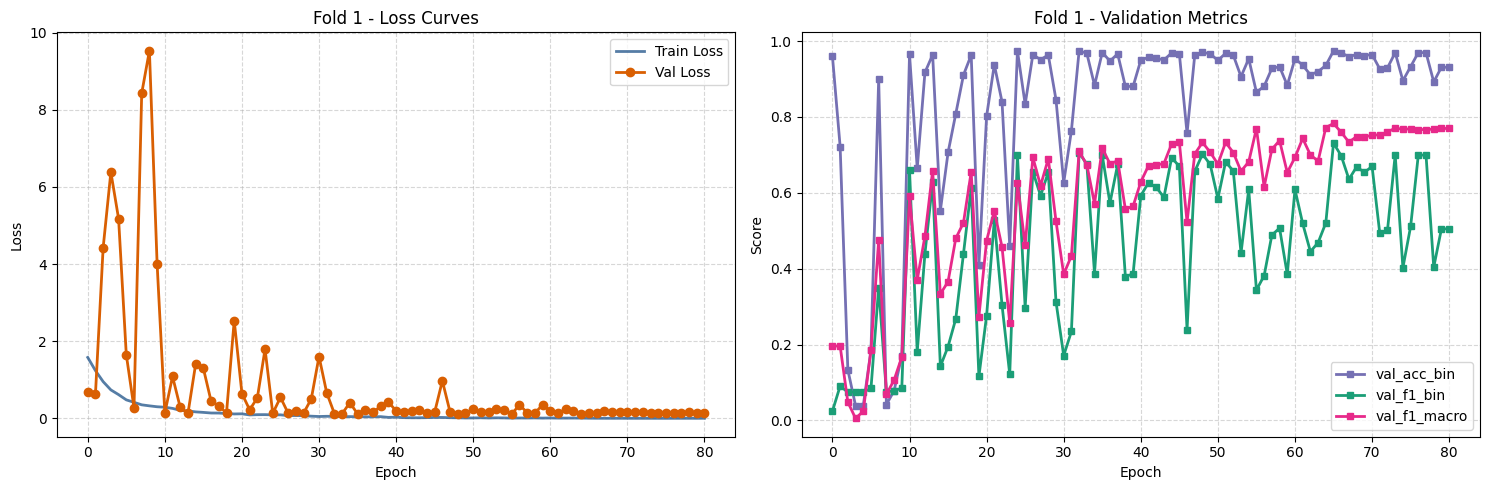

[2026-08-07 01:10:20] [INFO] Training Fold 2/5


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (8) is smaller than the logging interval Trainer(log_e

[2026-08-07 01:44:28] [INFO] Evaluating best checkpoint for Fold 2...
[2026-08-07 01:44:50] [INFO] Fold 2 complete. Optimal Epoch: 46
[2026-08-07 01:44:50] [INFO] Validation Macro F1: 0.7034


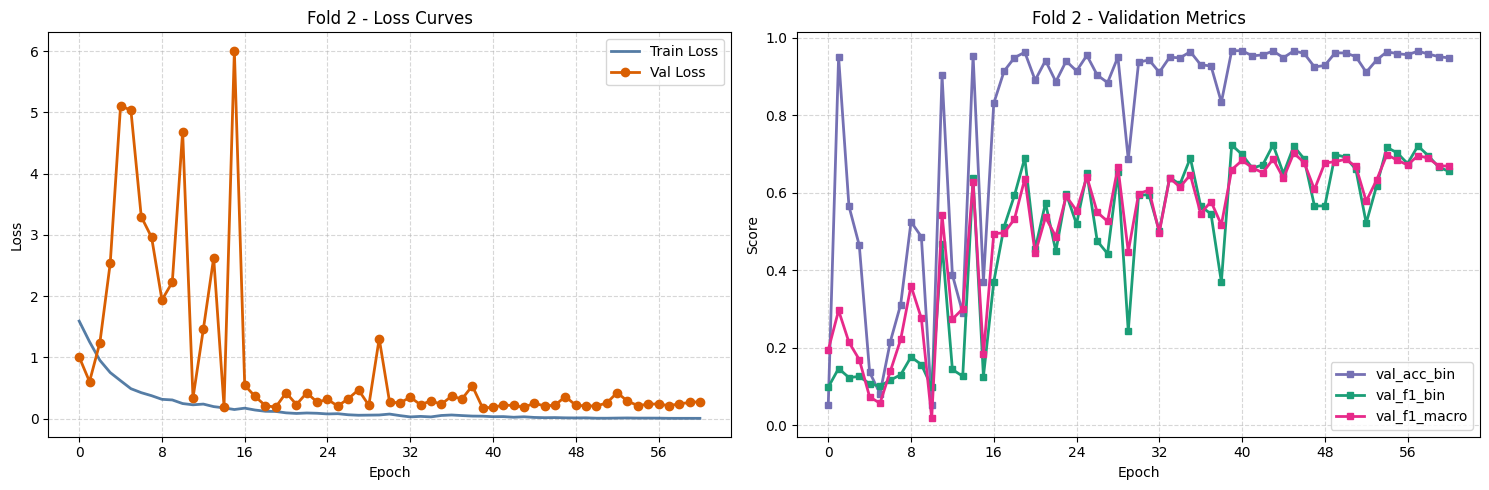

[2026-08-07 01:44:51] [INFO] Training Fold 3/5


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (9) is smaller than the logging interval Trainer(log_e

[2026-08-07 02:17:59] [INFO] Evaluating best checkpoint for Fold 3...
[2026-08-07 02:18:22] [INFO] Fold 3 complete. Optimal Epoch: 43
[2026-08-07 02:18:22] [INFO] Validation Macro F1: 0.7415


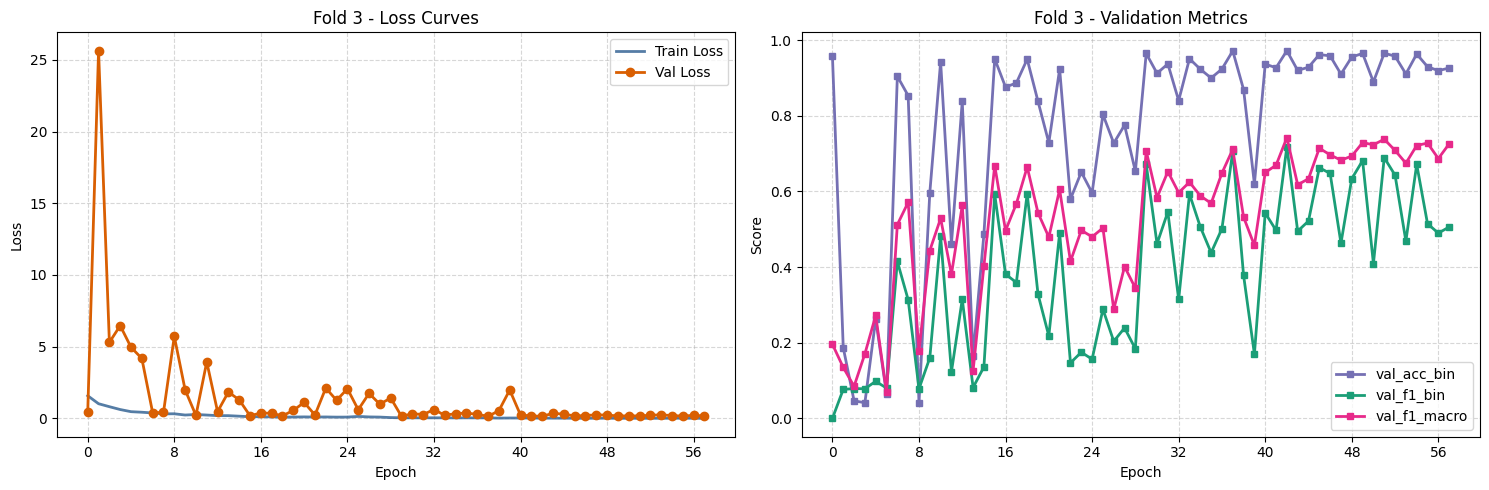

[2026-08-07 02:18:23] [INFO] Training Fold 4/5


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (9) is smaller than the logging interval Trainer(log_e

[2026-08-07 02:36:46] [INFO] Evaluating best checkpoint for Fold 4...
[2026-08-07 02:37:09] [INFO] Fold 4 complete. Optimal Epoch: 17
[2026-08-07 02:37:09] [INFO] Validation Macro F1: 0.6736


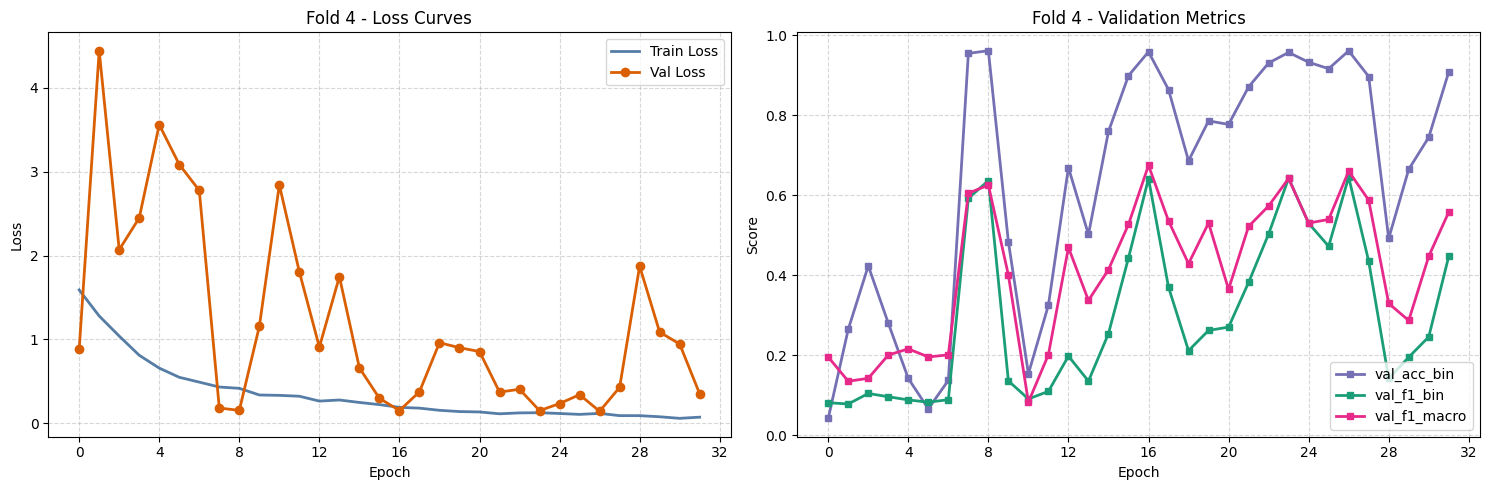

[2026-08-07 02:37:10] [INFO] Training Fold 5/5


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/loops/fit_loop.py:321: The number of training batches (9) is smaller than the logging interval Trainer(log_e

[2026-08-07 03:22:24] [INFO] Evaluating best checkpoint for Fold 5...
[2026-08-07 03:22:47] [INFO] Fold 5 complete. Optimal Epoch: 64
[2026-08-07 03:22:47] [INFO] Validation Macro F1: 0.7643


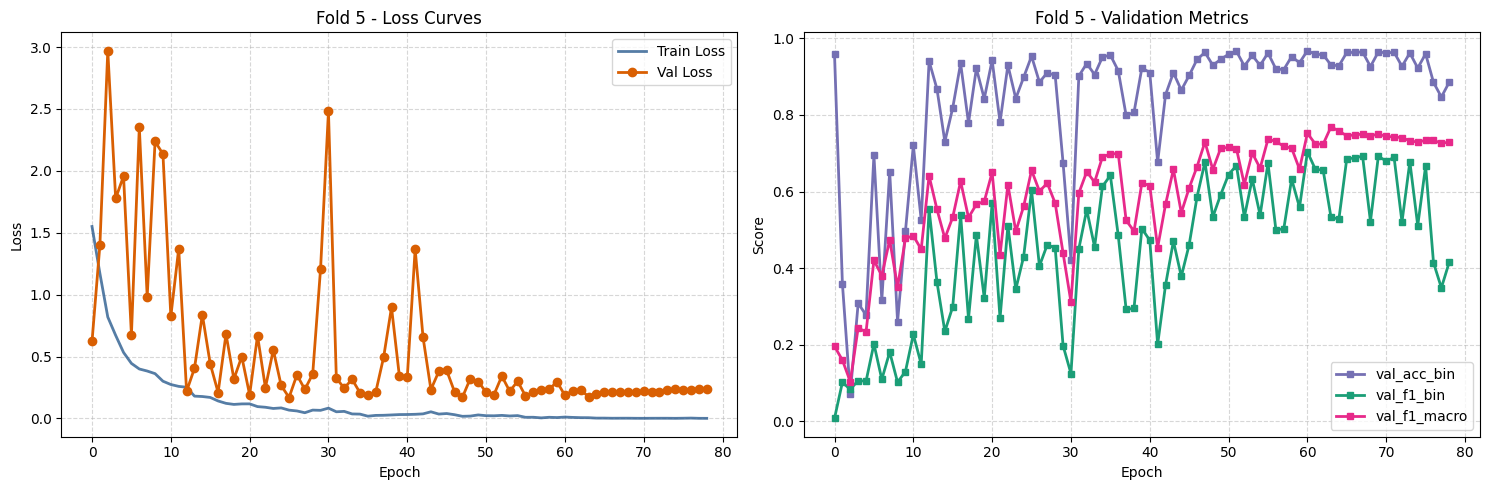

[2026-08-07 03:22:48] [INFO] Cross-Validation summary report (5-fold)
[2026-08-07 03:22:48] [INFO]   F1 Macro          : 0.7328 ± 0.0394
[2026-08-07 03:22:48] [INFO]   F1 Weighted       : 0.9694 ± 0.0053
[2026-08-07 03:22:48] [INFO]   Precision Macro   : 0.6550 ± 0.0309
[2026-08-07 03:22:48] [INFO]   Recall Macro      : 0.8600 ± 0.0464
[2026-08-07 03:22:48] [INFO]   Binary Accuracy   : 0.9680 ± 0.0055
[2026-08-07 03:22:48] [INFO] Cross-Validation Completed. Target Retraining Epochs: 46
[2026-08-07 03:22:48] [INFO] Retraining Production Model on Full Development Set...


Seed set to 42
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf(

[2026-08-07 03:34:06] [INFO] Saved deployment state dict (.pth) to: /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k/final_production_model.pth
[2026-08-07 03:34:06] [INFO] Saved framework checkpoint (.ckpt) to: /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k/final_production_model.ckpt
[2026-08-07 03:34:06] [INFO] Plotting final model training trajectories...


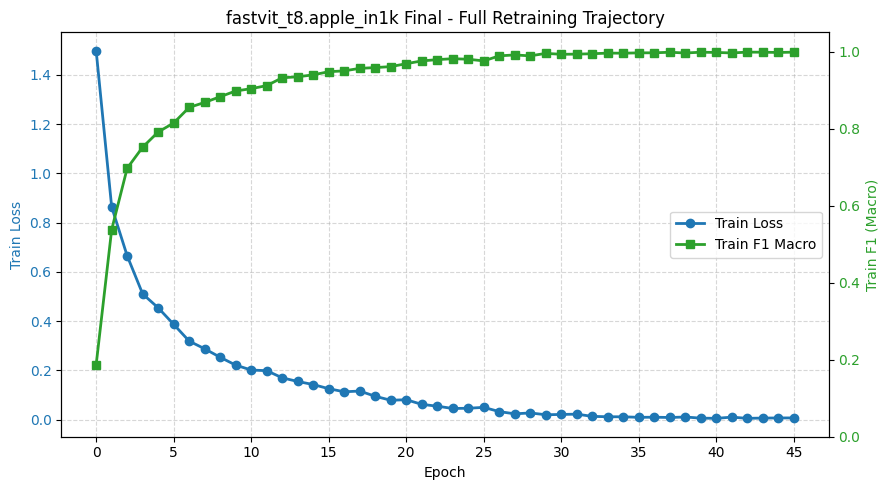

[2026-08-07 03:34:06] [INFO] Experiment Finished Successfully. All artifacts secured at: /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k
[2026-08-07 03:34:06] [INFO] Experiment Finished Successfully in 03h 11m 01s. All artifacts secured at: /kaggle/working/experiments/TILDA_64_undersampling_ratio1.0_fastvit_t8.apple_in1k
[2026-08-07 03:34:07] [INFO] Discord notification sent successfully.


In [6]:
# DATASET = "HKU"
DATASET = "TILDA"

# PSIZE = 32
PSIZE = 64
# PSIZE = 128

MODEL_NAME = "fastvit_t8.apple_in1k"
# MODEL_NAME = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
# MODEL_NAME = "resnet50.a1_in1k"

# EXPERIMENT_TYPE = "baseline"
EXPERIMENT_TYPE = "undersampling"
# EXPERIMENT_TYPE = "focal_loss"
# EXPERIMENT_TYPE = "wce"

# UNDER_RATIO = None
UNDER_RATIO = 1.0
# UNDER_RATIO = 5.0

results = run_experiment(dataset_name=DATASET, 
                         resolution=PSIZE, 
                         model_name=MODEL_NAME, 
                         experiment_type=EXPERIMENT_TYPE, 
                         undersample_ratio=UNDER_RATIO, 
                         num_epochs=N_EPOCHS, 
                         input_datasets_root=INPUT_DATASETS_ROOT,
                         batch_size=BATCH_SIZE)

dispatch_discord_notification(results)